# Phase 5: LightGBM Hyperparameter Tuning

## Overview

This notebook performs hyperparameter tuning on LightGBM to potentially improve upon the baseline model from Phase 4.

## Baseline Performance (Phase 4 LightGBM)

| Metric | Test Set | Validation (Aggregate) |
|--------|----------|------------------------|
| Recall | 1.0 | 1.0 (all datasets) |
| CRR | 0.9985 | 0.9947 - 0.9998 |
| NNI | 29.7 | 4.0 - 27.6 |
| FPR | 0.00145 | 0.0002 - 0.018 |

## Tuning Objectives

Since Recall is already at 1.0, the tuning goals are:

1. **Maintain 100% Recall** - Hard constraint (no missed detections)
2. **Improve CRR** - Reduce false positives to minimize analyst workload
3. **Reduce NNI** - Fewer files to review per true positive

## Hyperparameters to Tune

LightGBM has several key hyperparameters:

| Parameter | Description | Baseline | Search Range |
|-----------|-------------|----------|--------------|
| n_estimators | Number of boosting rounds | 300 | 100 - 1000 |
| max_depth | Maximum tree depth | 15 | 5 - 30 |
| num_leaves | Number of leaves per tree | 31 | 15 - 255 |
| learning_rate | Step size for updates | 0.05 | 0.01 - 0.3 |
| min_child_samples | Minimum samples in leaf | 20 | 5 - 100 |
| subsample | Row sampling ratio | 0.8 | 0.5 - 1.0 |
| colsample_bytree | Feature sampling ratio | 0.8 | 0.5 - 1.0 |
| reg_alpha | L1 regularization | 0 | 0 - 10 |
| reg_lambda | L2 regularization | 0 | 0 - 10 |

## Methodology

We use Optuna for Bayesian optimization, which is more efficient than grid search for high-dimensional parameter spaces. The optimization uses a custom objective function that:

1. Enforces Recall >= 0.999 as a hard constraint
2. Maximizes CRR (workload reduction) among valid configurations
3. Uses cross-validation to ensure robustness


In [31]:
# [Cell 2] Imports and Configuration

import pandas as pd
import numpy as np
from pathlib import Path
import warnings
import json
import time
warnings.filterwarnings('ignore')

# ML Libraries
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, fbeta_score, average_precision_score,
    make_scorer
)

# LightGBM
from lightgbm import LGBMClassifier

# Hyperparameter Optimization
import optuna
from optuna.samplers import TPESampler

# Imbalance handling
from imblearn.over_sampling import SMOTE

# Model persistence
import joblib

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# DIRECTORY CONFIGURATION
# =============================================================================

BASE_DIR = Path("/Users/soni/Github/Digital-Detectives_Thesis")
PHASE3_DIR = BASE_DIR / "data/Phase 3: Feature Engineering & Labeling/v1"
PHASE4_DIR = BASE_DIR / "data/Phase 4: Model Training/final version"
OUTPUT_DIR = BASE_DIR / "data/Phase 5: Hyperparameter Tuning"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Ground truth file
GROUND_TRUTH_PATH = BASE_DIR / "data/Suspicious Files (v1).csv"

print("=" * 70)
print("PHASE 5: LightGBM HYPERPARAMETER TUNING")
print("=" * 70)
print(f"\nPhase 3 features: {PHASE3_DIR}")
print(f"Phase 4 baseline: {PHASE4_DIR}")
print(f"Phase 5 output: {OUTPUT_DIR}")


PHASE 5: LightGBM HYPERPARAMETER TUNING

Phase 3 features: /Users/soni/Github/Digital-Detectives_Thesis/data/Phase 3: Feature Engineering & Labeling/v1
Phase 4 baseline: /Users/soni/Github/Digital-Detectives_Thesis/data/Phase 4: Model Training/final version
Phase 5 output: /Users/soni/Github/Digital-Detectives_Thesis/data/Phase 5: Hyperparameter Tuning


## Step 1: Load Configuration and Baseline Results

Load the training configuration from Phase 4 to ensure consistency in feature columns, datasets, and preprocessing.

In [32]:
# [Cell 4] Load Phase 4 Configuration

print("Loading Phase 4 configuration...")

# Load training config
config_path = PHASE4_DIR / "training_config.json"
with open(config_path, 'r') as f:
    training_config = json.load(f)

# Extract configuration
feature_columns = training_config['feature_columns']
TRAINING_DATASETS = training_config['training_datasets']
VALIDATION_DATASETS = training_config['validation_datasets']

print(f"\nFeature columns: {len(feature_columns)}")
print(f"Training datasets: {len(TRAINING_DATASETS)}")
print(f"Validation datasets: {len(VALIDATION_DATASETS)}")

# Load baseline model comparison
baseline_df = pd.read_csv(PHASE4_DIR / "model_comparison_forensic.csv")
lgbm_baseline = baseline_df[baseline_df['Model'] == 'LightGBM'].iloc[0]

print(f"\n" + "=" * 70)
print("BASELINE LightGBM PERFORMANCE (Phase 4)")
print("=" * 70)
print(f"Recall:    {lgbm_baseline['Recall']:.4f}")
print(f"CRR:       {lgbm_baseline['CRR']:.6f} ({lgbm_baseline['CRR']*100:.4f}% files excluded)")
print(f"NNI:       {lgbm_baseline['NNI']:.2f}")
print(f"FPR:       {lgbm_baseline['FPR']:.6f}")
print(f"F2:        {lgbm_baseline['F2']:.4f}")
print(f"Threshold: {lgbm_baseline['Threshold']:.4f}")
print(f"TP: {int(lgbm_baseline['TP'])}, FP: {int(lgbm_baseline['FP'])}, FN: {int(lgbm_baseline['FN'])}")


Loading Phase 4 configuration...

Feature columns: 29
Training datasets: 23
Validation datasets: 4

BASELINE LightGBM PERFORMANCE (Phase 4)
Recall:    1.0000
CRR:       0.998502 (99.8502% files excluded)
NNI:       29.70
FPR:       0.001448
F2:        0.1484
Threshold: 0.0200
TP: 10, FP: 287, FN: 0


## Step 2: Load and Prepare Training Data

Load the same training data used in Phase 4 to ensure fair comparison.
The ground truth matching function handles the special case of LoneWolf dataset where filenames include paths.


In [33]:
# [Cell 6] Ground Truth Matching Function

def match_ground_truth(df_features, df_gt, dataset_id):
    """
    Match ground truth labels to file features.
    
    For most datasets: match on FileName
    For LoneWolf: match on FilePath (ground truth uses /Dropbox/file.ext format)
    """
    df = df_features.copy()
    df['is_timestomped'] = 0
    
    gt_dataset = df_gt[df_gt['dataID'] == dataset_id]
    
    if len(gt_dataset) == 0:
        return df, 0
    
    matched_count = 0
    
    if dataset_id == "LoneWolf":
        for _, gt_row in gt_dataset.iterrows():
            gt_path = gt_row['FileName']
            
            if gt_path.startswith('/Dropbox/'):
                gt_filename = gt_path.split('/')[-1]
                mask = (df['FilePath'].str.contains('/Dropbox/', na=False)) & \
                       (df['FileName'] == gt_filename)
            else:
                mask = df['FilePath'] == gt_path
            
            matches = mask.sum()
            if matches > 0:
                df.loc[mask, 'is_timestomped'] = 1
                matched_count += matches
    else:
        for _, gt_row in gt_dataset.iterrows():
            gt_filename = gt_row['FileName']
            mask = df['FileName'] == gt_filename
            matches = mask.sum()
            if matches > 0:
                df.loc[mask, 'is_timestomped'] = 1
                matched_count += matches
    
    return df, matched_count

print("Ground truth matching function defined.")


Ground truth matching function defined.


In [34]:
# [Cell 7] Load Training Data

print("Loading training data...")
print("=" * 70)

# Load ground truth
df_ground_truth = pd.read_csv(GROUND_TRUTH_PATH)
print(f"Ground truth: {len(df_ground_truth)} known timestomped files")

# Load all training datasets
all_training_data = []

for dataset_id in TRAINING_DATASETS:
    features_path = PHASE3_DIR / f"file_features_{dataset_id}.csv"
    
    if not features_path.exists():
        print(f"  {dataset_id}: SKIPPED (not found)")
        continue
    
    df_features = pd.read_csv(features_path, low_memory=False)
    df_labeled, matched = match_ground_truth(df_features, df_ground_truth, dataset_id)
    
    expected = len(df_ground_truth[df_ground_truth['dataID'] == dataset_id])
    print(f"  {dataset_id}: {len(df_labeled):,} files, {matched}/{expected} timestomped matched")
    
    all_training_data.append(df_labeled)

# Combine all training data
df_train_all = pd.concat(all_training_data, ignore_index=True)

print("=" * 70)
print(f"\nTotal training files: {len(df_train_all):,}")
print(f"Total timestomped: {df_train_all['is_timestomped'].sum()}")
print(f"Imbalance ratio: {(df_train_all['is_timestomped'] == 0).sum() / df_train_all['is_timestomped'].sum():.0f}:1")


Loading training data...
Ground truth: 64 known timestomped files
  01-PE: 37,375 files, 1/1 timestomped matched
  02-PE: 105,251 files, 1/1 timestomped matched
  03-PE: 109,985 files, 1/1 timestomped matched
  04-PE: 7,882 files, 1/1 timestomped matched
  05-PE: 9,451 files, 1/1 timestomped matched
  06-PE: 9,434 files, 1/1 timestomped matched
  07-PE: 110,336 files, 1/1 timestomped matched
  08-PE: 110,541 files, 1/1 timestomped matched
  09-PE: 111,889 files, 1/1 timestomped matched
  10-PE: 110,574 files, 0/0 timestomped matched
  11-PE: 9,415 files, 1/1 timestomped matched
  12-PE: 9,160 files, 1/1 timestomped matched
  01-APT17: 31,455 files, 1/1 timestomped matched
  02-APT19: 21,334 files, 23/13 timestomped matched
  03-APT21: 28,028 files, 1/1 timestomped matched
  04-APT28: 29,399 files, 1/1 timestomped matched
  05-APT29: 29,860 files, 6/6 timestomped matched
  06-APT30: 22,266 files, 1/1 timestomped matched
  07-APT37: 29,426 files, 1/1 timestomped matched
  08-APT38: 20,47

In [35]:
# [Cell 8] Prepare Feature Matrix and Labels

print("Preparing features and labels...")

# Feature matrix
X = df_train_all[feature_columns].copy()
X = X.fillna(0)

# Convert ALL object columns to numeric (handles string "True"/"False")
for col in X.columns:
    if X[col].dtype == 'object':
        # Try to convert string booleans to int
        if X[col].isin(['True', 'False', True, False, 'true', 'false', '1', '0', 1, 0]).all():
            X[col] = X[col].map({
                'True': 1, 'False': 0, 
                True: 1, False: 0,
                'true': 1, 'false': 0,
                '1': 1, '0': 0,
                1: 1, 0: 0
            }).fillna(0).astype(int)
        else:
            # Force convert to numeric
            X[col] = pd.to_numeric(X[col], errors='coerce').fillna(0)

# Convert boolean columns to int
bool_cols = X.select_dtypes(include=['bool']).columns
X[bool_cols] = X[bool_cols].astype(int)

# Ensure all columns are numeric
X = X.astype(float)

# Target variable
y = df_train_all['is_timestomped'].astype(int)

print(f"Feature matrix shape: {X.shape}")
print(f"Positive samples: {y.sum()}")
print(f"Negative samples: {(y == 0).sum()}")

# Verify all dtypes are numeric
print(f"\nData types check:")
non_numeric = X.select_dtypes(exclude=['int64', 'float64', 'int32', 'float32']).columns
if len(non_numeric) > 0:
    print(f"  WARNING: Non-numeric columns: {list(non_numeric)}")
else:
    print(f"  All {len(X.columns)} columns are numeric")


Preparing features and labels...
Feature matrix shape: (991403, 29)
Positive samples: 52
Negative samples: 991351

Data types check:
  All 29 columns are numeric


In [36]:
# [Cell 9] Train-Test Split (Same as Phase 4)

print("Performing train-test split...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTraining set: {len(X_train):,} samples")
print(f"  Positive: {y_train.sum()}")
print(f"  Negative: {(y_train == 0).sum()}")

print(f"\nTest set: {len(X_test):,} samples")
print(f"  Positive: {y_test.sum()}")
print(f"  Negative: {(y_test == 0).sum()}")


Performing train-test split...

Training set: 793,122 samples
  Positive: 42
  Negative: 793080

Test set: 198,281 samples
  Positive: 10
  Negative: 198271


In [37]:
# [Cell 10] Apply SMOTE (Same as Phase 4)

print("Applying SMOTE for class balancing...")

n_positive = y_train.sum()
n_negative = (y_train == 0).sum()

# Same SMOTE configuration as Phase 4
target_positive = min(n_negative // 100, n_positive * 100)
target_positive = max(target_positive, n_positive)

smote = SMOTE(
    sampling_strategy={1: target_positive},
    random_state=42,
    k_neighbors=min(5, n_positive - 1) if n_positive > 1 else 1
)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"  Positive: {(y_train_balanced == 1).sum()}")
print(f"  Negative: {(y_train_balanced == 0).sum()}")
print(f"  New ratio: {(y_train_balanced == 0).sum() / (y_train_balanced == 1).sum():.0f}:1")


Applying SMOTE for class balancing...

After SMOTE:
  Positive: 4200
  Negative: 793080
  New ratio: 189:1


## Step 3: Define Forensic Metrics

Define the same forensic metrics used in Phase 4 to ensure consistent evaluation.
The key metrics are:
- **Recall**: Must be 1.0 (hard constraint)
- **CRR**: Candidate Reduction Rate (higher is better)
- **NNI**: Number Needed to Investigate (lower is better)


In [38]:
# [Cell 12] Forensic Metrics Functions

def compute_forensic_metrics(y_true, y_pred, y_prob=None, total_files=None):
    """
    Compute forensic-appropriate metrics.
    """
    if total_files is None:
        total_files = len(y_true)
    
    cm = confusion_matrix(y_true, y_pred)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
    else:
        tn, fp, fn, tp = 0, 0, 0, 0
    
    # Primary metrics
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    flagged = tp + fp
    crr = 1.0 - (flagged / total_files) if total_files > 0 else 0.0
    nni = flagged / tp if tp > 0 else float('inf')
    
    # Secondary metrics
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    
    # Supplementary
    f2 = fbeta_score(y_true, y_pred, beta=2, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    if y_prob is not None and len(np.unique(y_true)) > 1:
        aucpr = average_precision_score(y_true, y_prob)
    else:
        aucpr = np.nan
    
    return {
        'Recall': recall,
        'CRR': crr,
        'NNI': nni,
        'FPR': fpr,
        'Precision': precision,
        'F2': f2,
        'F1': f1,
        'AUCPR': aucpr,
        'TP': tp,
        'FP': fp,
        'TN': tn,
        'FN': fn
    }


def find_recall_constrained_threshold(model, X, y, target_recall=1.0):
    """
    Find the lowest threshold that achieves target recall.
    This maximizes CRR while maintaining the recall constraint.
    """
    y_prob = model.predict_proba(X)[:, 1]
    n_positive = y.sum()
    
    if n_positive == 0:
        return 0.5
    
    best_threshold = 0.01
    for threshold in np.arange(0.99, 0.00, -0.01):
        y_pred = (y_prob >= threshold).astype(int)
        recall = recall_score(y, y_pred, zero_division=0)
        
        if recall >= target_recall:
            best_threshold = threshold
            break
    
    return best_threshold


print("Forensic metrics functions defined.")


Forensic metrics functions defined.


## Step 4: Define Optuna Objective Function

The objective function for hyperparameter optimization:

1. Creates a LightGBM model with the suggested hyperparameters
2. Uses 3-fold stratified cross-validation to evaluate
3. Finds the optimal threshold for 100% recall
4. Returns CRR as the optimization target (higher is better)

The function penalizes configurations that cannot achieve 100% recall.


In [39]:
# [Cell 14] Optuna Objective Function

def objective(trial):
    """
    Optuna objective function for LightGBM hyperparameter tuning.
    
    Objective: Maximize CRR while maintaining 100% Recall
    """
    # Suggest hyperparameters
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=50),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'num_leaves': trial.suggest_int('num_leaves', 15, 255),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'class_weight': 'balanced',
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }
    
    # Ensure num_leaves <= 2^max_depth
    if params['num_leaves'] > 2 ** params['max_depth']:
        params['num_leaves'] = 2 ** params['max_depth'] - 1
    
    # 3-fold stratified cross-validation
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    
    recalls = []
    crrs = []
    
    for train_idx, val_idx in cv.split(X_train_balanced, y_train_balanced):
        X_fold_train = X_train_balanced.iloc[train_idx] if hasattr(X_train_balanced, 'iloc') else X_train_balanced[train_idx]
        y_fold_train = y_train_balanced.iloc[train_idx] if hasattr(y_train_balanced, 'iloc') else y_train_balanced[train_idx]
        X_fold_val = X_train_balanced.iloc[val_idx] if hasattr(X_train_balanced, 'iloc') else X_train_balanced[val_idx]
        y_fold_val = y_train_balanced.iloc[val_idx] if hasattr(y_train_balanced, 'iloc') else y_train_balanced[val_idx]
        
        # Train model
        model = LGBMClassifier(**params)
        model.fit(X_fold_train, y_fold_train)
        
        # Find threshold for 100% recall
        threshold = find_recall_constrained_threshold(model, X_fold_val, y_fold_val, target_recall=1.0)
        
        # Evaluate
        y_prob = model.predict_proba(X_fold_val)[:, 1]
        y_pred = (y_prob >= threshold).astype(int)
        
        recall = recall_score(y_fold_val, y_pred, zero_division=0)
        
        # CRR calculation
        tp = ((y_pred == 1) & (y_fold_val == 1)).sum()
        fp = ((y_pred == 1) & (y_fold_val == 0)).sum()
        crr = 1.0 - (tp + fp) / len(y_fold_val)
        
        recalls.append(recall)
        crrs.append(crr)
    
    mean_recall = np.mean(recalls)
    mean_crr = np.mean(crrs)
    
    # Penalize if recall is not 100%
    if mean_recall < 0.999:
        return -1.0  # Heavily penalize
    
    return mean_crr


print("Optuna objective function defined.")
print("\nObjective: Maximize CRR while maintaining 100% Recall")


Optuna objective function defined.

Objective: Maximize CRR while maintaining 100% Recall


## Step 5: Run Hyperparameter Optimization

Run Optuna optimization with:
- 100 trials (can be adjusted based on time constraints)
- TPE (Tree-structured Parzen Estimator) sampler for efficient search
- Pruning disabled to ensure each configuration is fully evaluated

This process may take 15-30 minutes depending on hardware.


In [40]:
# [Cell 16] Run Optuna Optimization

print("=" * 70)
print("STARTING HYPERPARAMETER OPTIMIZATION")
print("=" * 70)

# Create Optuna study
study = optuna.create_study(
    direction='maximize',  # Maximize CRR
    sampler=TPESampler(seed=42),
    study_name='lightgbm_tuning'
)

# Optimize
start_time = time.time()

study.optimize(
    objective,
    n_trials=100,
    show_progress_bar=True,
    n_jobs=1  # Sequential for reproducibility
)

elapsed_time = time.time() - start_time

print(f"\n" + "=" * 70)
print("OPTIMIZATION COMPLETE")
print("=" * 70)
print(f"Total time: {elapsed_time / 60:.1f} minutes")
print(f"Trials completed: {len(study.trials)}")
print(f"Best CRR achieved: {study.best_value:.6f}")


[I 2026-01-06 16:33:17,666] A new study created in memory with name: lightgbm_tuning


STARTING HYPERPARAMETER OPTIMIZATION


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-01-06 16:33:45,029] Trial 0 finished with value: 0.9930062211519165 and parameters: {'n_estimators': 450, 'max_depth': 29, 'num_leaves': 191, 'learning_rate': 0.07661100707771368, 'min_child_samples': 19, 'subsample': 0.5779972601681014, 'colsample_bytree': 0.5290418060840998, 'reg_alpha': 0.6245760287469887, 'reg_lambda': 0.002570603566117596}. Best is trial 0 with value: 0.9930062211519165.
[I 2026-01-06 16:34:11,663] Trial 1 finished with value: -1.0 and parameters: {'n_estimators': 750, 'max_depth': 5, 'num_leaves': 248, 'learning_rate': 0.1696753360719655, 'min_child_samples': 25, 'subsample': 0.5909124836035503, 'colsample_bytree': 0.5917022549267169, 'reg_alpha': 5.472429642032189e-06, 'reg_lambda': 0.00052821153945323}. Best is trial 0 with value: 0.9930062211519165.
[I 2026-01-06 16:34:42,089] Trial 2 finished with value: 0.9924292594822396 and parameters: {'n_estimators': 500, 'max_depth': 12, 'num_leaves': 162, 'learning_rate': 0.01607123851203988, 'min_child_samples

In [41]:
# [Cell 17] Display Best Hyperparameters

print("=" * 70)
print("BEST HYPERPARAMETERS")
print("=" * 70)

best_params = study.best_params

print(f"\n{'Parameter':<25} {'Value':>15} {'Baseline':>15}")
print("-" * 60)

# Baseline parameters from Phase 4
baseline_params = {
    'n_estimators': 300,
    'max_depth': 15,
    'num_leaves': 31,
    'learning_rate': 0.05,
    'min_child_samples': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0,
    'reg_lambda': 0
}

for param, value in best_params.items():
    baseline_val = baseline_params.get(param, 'N/A')
    if isinstance(value, float):
        print(f"{param:<25} {value:>15.6f} {baseline_val:>15}")
    else:
        print(f"{param:<25} {value:>15} {baseline_val:>15}")

# Ensure num_leaves constraint
if best_params['num_leaves'] > 2 ** best_params['max_depth']:
    best_params['num_leaves'] = 2 ** best_params['max_depth'] - 1
    print(f"\nAdjusted num_leaves to {best_params['num_leaves']} (must be <= 2^max_depth)")


BEST HYPERPARAMETERS

Parameter                           Value        Baseline
------------------------------------------------------------
n_estimators                          550             300
max_depth                              27              15
num_leaves                            191              31
learning_rate                    0.131045            0.05
min_child_samples                      32              20
subsample                        0.652024             0.8
colsample_bytree                 0.715423             0.8
reg_alpha                        0.000006               0
reg_lambda                       0.035291               0


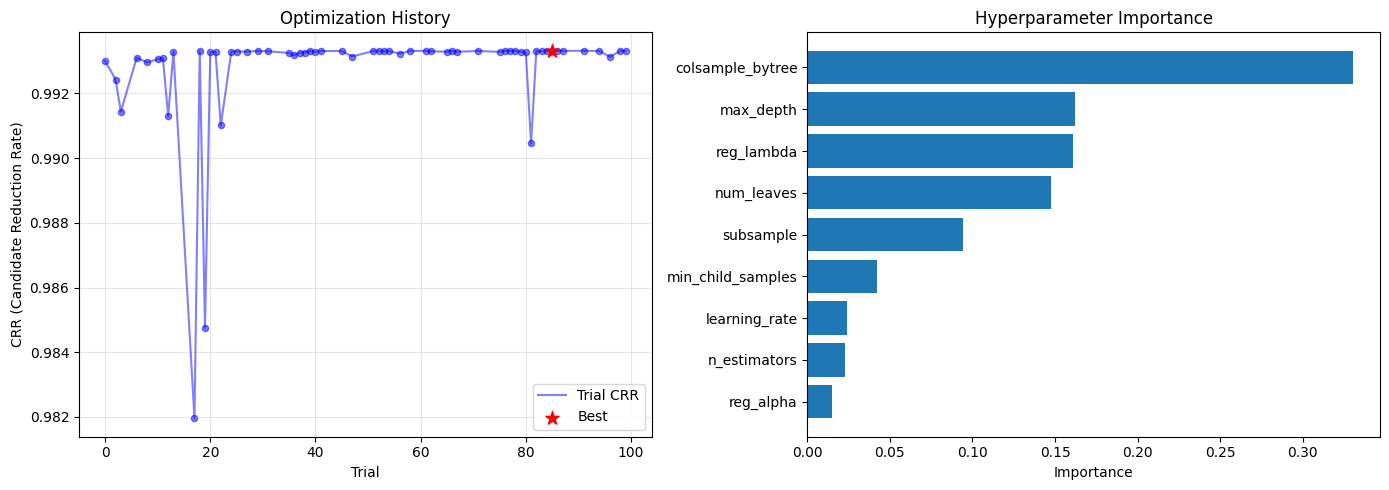


Plot saved to: /Users/soni/Github/Digital-Detectives_Thesis/data/Phase 5: Hyperparameter Tuning/optimization_history.png


In [42]:
# [Cell 18] Optimization History Visualization

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Optimization history
trials_df = study.trials_dataframe()
valid_trials = trials_df[trials_df['value'] > 0]  # Exclude penalized trials

axes[0].plot(valid_trials.index, valid_trials['value'], 'b-', alpha=0.5, label='Trial CRR')
axes[0].scatter(valid_trials.index, valid_trials['value'], c='blue', s=20, alpha=0.5)

# Highlight best
best_idx = valid_trials['value'].idxmax()
axes[0].scatter(best_idx, valid_trials.loc[best_idx, 'value'], 
                c='red', s=100, marker='*', label='Best', zorder=5)

axes[0].set_xlabel('Trial')
axes[0].set_ylabel('CRR (Candidate Reduction Rate)')
axes[0].set_title('Optimization History')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Parameter importance
try:
    importance = optuna.importance.get_param_importances(study)
    params_sorted = sorted(importance.items(), key=lambda x: x[1], reverse=True)
    params = [p[0] for p in params_sorted]
    values = [p[1] for p in params_sorted]
    
    axes[1].barh(params, values)
    axes[1].set_xlabel('Importance')
    axes[1].set_title('Hyperparameter Importance')
    axes[1].invert_yaxis()
except:
    axes[1].text(0.5, 0.5, 'Importance calculation not available', 
                 ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "optimization_history.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPlot saved to: {OUTPUT_DIR / 'optimization_history.png'}")


## Step 6: Train Final Tuned Model

Train the final LightGBM model using the best hyperparameters found by Optuna.
We train on the full balanced training set (same as Phase 4) for fair comparison.

In [43]:
# [Cell 20] Train Final Tuned Model

print("=" * 70)
print("TRAINING FINAL TUNED MODEL")
print("=" * 70)

# Create final model with best parameters
final_params = {
    **best_params,
    'class_weight': 'balanced',
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

# Ensure num_leaves constraint
if final_params['num_leaves'] > 2 ** final_params['max_depth']:
    final_params['num_leaves'] = 2 ** final_params['max_depth'] - 1

print("\nFinal model parameters:")
for param, value in final_params.items():
    print(f"  {param}: {value}")

# Train model
tuned_model = LGBMClassifier(**final_params)
tuned_model.fit(X_train_balanced, y_train_balanced)

print("\nModel training complete.")


TRAINING FINAL TUNED MODEL

Final model parameters:
  n_estimators: 550
  max_depth: 27
  num_leaves: 191
  learning_rate: 0.13104470848761152
  min_child_samples: 32
  subsample: 0.6520239681903617
  colsample_bytree: 0.715422657616046
  reg_alpha: 6.3629422942703e-06
  reg_lambda: 0.03529106557086545
  class_weight: balanced
  random_state: 42
  n_jobs: -1
  verbose: -1

Model training complete.


In [44]:
# [Cell 21] Find Optimal Threshold for Tuned Model

print("Finding optimal threshold for 100% recall...")

# Find threshold on test set
tuned_threshold = find_recall_constrained_threshold(
    tuned_model, X_test.values, y_test, target_recall=1.0
)

print(f"Optimal threshold: {tuned_threshold:.4f}")
print(f"Baseline threshold: {lgbm_baseline['Threshold']:.4f}")


Finding optimal threshold for 100% recall...
Optimal threshold: 0.0100
Baseline threshold: 0.0200


## Step 7: Evaluate Tuned Model on Test Set

Compare the tuned model against the baseline using the same test set.
All metrics are computed using the forensic metrics framework from Phase 4.

In [45]:
# [Cell 23] Evaluate Tuned Model on Test Set

print("=" * 70)
print("TEST SET EVALUATION: TUNED vs BASELINE")
print("=" * 70)

# Tuned model predictions
y_prob_tuned = tuned_model.predict_proba(X_test.values)[:, 1]
y_pred_tuned = (y_prob_tuned >= tuned_threshold).astype(int)

# Compute metrics
tuned_metrics = compute_forensic_metrics(y_test, y_pred_tuned, y_prob_tuned, len(y_test))
tuned_metrics['Threshold'] = tuned_threshold

# Comparison table
print(f"\n{'Metric':<20} {'Tuned':>15} {'Baseline':>15} {'Change':>15}")
print("-" * 70)

comparison_metrics = ['Recall', 'CRR', 'NNI', 'FPR', 'F2', 'Precision']
for metric in comparison_metrics:
    tuned_val = tuned_metrics[metric]
    baseline_val = lgbm_baseline[metric]
    
    if metric == 'NNI':
        # Lower is better for NNI
        change = baseline_val - tuned_val
        change_str = f"{change:+.2f}"
        better = "(better)" if change > 0 else "(worse)" if change < 0 else ""
    elif metric in ['Recall', 'CRR', 'F2', 'Precision']:
        # Higher is better
        change = tuned_val - baseline_val
        change_str = f"{change:+.6f}"
        better = "(better)" if change > 0 else "(worse)" if change < 0 else ""
    else:
        # Lower is better for FPR
        change = baseline_val - tuned_val
        change_str = f"{change:+.6f}"
        better = "(better)" if change > 0 else "(worse)" if change < 0 else ""
    
    print(f"{metric:<20} {tuned_val:>15.6f} {baseline_val:>15.6f} {change_str:>10} {better}")

print(f"\n{'Threshold':<20} {tuned_threshold:>15.4f} {lgbm_baseline['Threshold']:>15.4f}")

# Confusion matrix comparison
print(f"\n" + "-" * 70)
print("Confusion Matrix Comparison:")
print(f"{'Component':<20} {'Tuned':>15} {'Baseline':>15} {'Change':>15}")
print("-" * 70)
for comp in ['TP', 'FP', 'TN', 'FN']:
    tuned_val = tuned_metrics[comp]
    baseline_val = int(lgbm_baseline[comp])
    change = tuned_val - baseline_val
    change_str = f"{change:+d}"
    print(f"{comp:<20} {tuned_val:>15} {baseline_val:>15} {change_str:>15}")


TEST SET EVALUATION: TUNED vs BASELINE

Metric                         Tuned        Baseline          Change
----------------------------------------------------------------------
Recall                      0.800000        1.000000  -0.200000 (worse)
CRR                         0.998553        0.998502  +0.000050 (better)
NNI                        35.875000       29.700000      -6.18 (worse)
FPR                         0.001407        0.001448  +0.000040 (better)
F2                          0.122324        0.148368  -0.026044 (worse)
Precision                   0.027875        0.033670  -0.005795 (worse)

Threshold                     0.0100          0.0200

----------------------------------------------------------------------
Confusion Matrix Comparison:
Component                      Tuned        Baseline          Change
----------------------------------------------------------------------
TP                                 8              10              -2
FP                    

## Step 8: Validation on Held-Out Datasets

The most important test: validate the tuned model on the same held-out datasets used in Phase 4.
These datasets were never seen during training or hyperparameter optimization.

Validation datasets:
- 09-APT40
- 12-Kimsuky
- 13-Winnti731
- LoneWolf


In [46]:
# [Cell 25] Validation Function

def validate_on_dataset(dataset_name, model, feature_columns, df_gt, threshold):
    """
    Validate model on a single dataset.
    """
    features_path = PHASE3_DIR / f"file_features_{dataset_name}.csv"
    
    if not features_path.exists():
        print(f"  {dataset_name}: File not found")
        return None
    
    # Load and prepare data
    df_val = pd.read_csv(features_path, low_memory=False)
    df_val_labeled, matched = match_ground_truth(df_val, df_gt, dataset_name)
    
    X_val = df_val_labeled[feature_columns].copy()
    X_val = X_val.fillna(0)
    bool_cols = X_val.select_dtypes(include=['bool']).columns
    X_val[bool_cols] = X_val[bool_cols].astype(int)
    
    y_val = df_val_labeled['is_timestomped'].astype(int)
    
    # Predictions
    y_prob = model.predict_proba(X_val.values)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    
    # Metrics
    metrics = compute_forensic_metrics(y_val, y_pred, y_prob, len(y_val))
    metrics['Dataset'] = dataset_name
    metrics['Threshold'] = threshold
    metrics['Total'] = len(y_val)
    metrics['GT_Positive'] = y_val.sum()
    
    return metrics


print("Validation function defined.")


Validation function defined.


In [47]:
# [Cell 26] Run Validation on All Datasets

print("=" * 70)
print("VALIDATION ON HELD-OUT DATASETS")
print("=" * 70)

# Load baseline validation results
baseline_val_df = pd.read_csv(PHASE4_DIR / "validation_results_forensic.csv")
baseline_val_lgbm = baseline_val_df[baseline_val_df['Model'] == 'LightGBM']

tuned_validation_results = []

for dataset in VALIDATION_DATASETS:
    print(f"\n--- {dataset} ---")
    
    # Tuned model
    tuned_result = validate_on_dataset(
        dataset, tuned_model, feature_columns, df_ground_truth, tuned_threshold
    )
    
    if tuned_result is None:
        continue
    
    tuned_validation_results.append(tuned_result)
    
    # Get baseline for comparison
    baseline_row = baseline_val_lgbm[baseline_val_lgbm['Dataset'] == dataset]
    
    if len(baseline_row) > 0:
        baseline_row = baseline_row.iloc[0]
        
        print(f"  {'Metric':<15} {'Tuned':>12} {'Baseline':>12} {'Change':>12}")
        print(f"  {'-'*55}")
        
        for metric in ['Recall', 'CRR', 'NNI']:
            tuned_val = tuned_result[metric]
            baseline_val = baseline_row[metric]
            
            if metric == 'NNI':
                change = baseline_val - tuned_val
                better = "(+)" if change > 0 else "(-)" if change < 0 else ""
            else:
                change = tuned_val - baseline_val
                better = "(+)" if change > 0 else "(-)" if change < 0 else ""
            
            if metric == 'NNI':
                print(f"  {metric:<15} {tuned_val:>12.2f} {baseline_val:>12.2f} {change:>+10.2f} {better}")
            else:
                print(f"  {metric:<15} {tuned_val:>12.4f} {baseline_val:>12.4f} {change:>+10.6f} {better}")
        
        print(f"  TP: {tuned_result['TP']}, FP: {tuned_result['FP']}, FN: {tuned_result['FN']}")

# Create validation results dataframe
df_tuned_validation = pd.DataFrame(tuned_validation_results)


VALIDATION ON HELD-OUT DATASETS

--- 09-APT40 ---
  Metric                 Tuned     Baseline       Change
  -------------------------------------------------------
  Recall                1.0000       1.0000  +0.000000 
  CRR                   0.9990       0.9990  +0.000000 
  NNI                     5.00         5.00      +0.00 
  TP: 6, FP: 24, FN: 0

--- 12-Kimsuky ---
  Metric                 Tuned     Baseline       Change
  -------------------------------------------------------
  Recall                1.0000       1.0000  +0.000000 
  CRR                   0.9986       0.9985  +0.000135 (+)
  NNI                     7.00         7.67      +0.67 (+)
  TP: 3, FP: 18, FN: 0

--- 13-Winnti731 ---
  Metric                 Tuned     Baseline       Change
  -------------------------------------------------------
  Recall                1.0000       1.0000  +0.000000 
  CRR                   0.9998       0.9998  +0.000000 (+)
  NNI                     4.00         4.00      +0.00 
  TP

In [48]:
# [Cell 27] Aggregate Validation Comparison

print("\n" + "=" * 70)
print("AGGREGATE VALIDATION COMPARISON")
print("=" * 70)

# Aggregate tuned results
tuned_agg = {
    'TP': df_tuned_validation['TP'].sum(),
    'FP': df_tuned_validation['FP'].sum(),
    'TN': df_tuned_validation['TN'].sum(),
    'FN': df_tuned_validation['FN'].sum(),
    'Total': df_tuned_validation['Total'].sum()
}
tuned_agg['Recall'] = tuned_agg['TP'] / (tuned_agg['TP'] + tuned_agg['FN']) if (tuned_agg['TP'] + tuned_agg['FN']) > 0 else 0
tuned_agg['CRR'] = 1 - (tuned_agg['TP'] + tuned_agg['FP']) / tuned_agg['Total']
tuned_agg['NNI'] = (tuned_agg['TP'] + tuned_agg['FP']) / tuned_agg['TP'] if tuned_agg['TP'] > 0 else float('inf')
tuned_agg['FPR'] = tuned_agg['FP'] / (tuned_agg['FP'] + tuned_agg['TN'])

# Aggregate baseline results
baseline_agg = {
    'TP': baseline_val_lgbm['TP'].sum(),
    'FP': baseline_val_lgbm['FP'].sum(),
    'TN': baseline_val_lgbm['TN'].sum(),
    'FN': baseline_val_lgbm['FN'].sum(),
    'Total': baseline_val_lgbm['Total'].sum()
}
baseline_agg['Recall'] = baseline_agg['TP'] / (baseline_agg['TP'] + baseline_agg['FN']) if (baseline_agg['TP'] + baseline_agg['FN']) > 0 else 0
baseline_agg['CRR'] = 1 - (baseline_agg['TP'] + baseline_agg['FP']) / baseline_agg['Total']
baseline_agg['NNI'] = (baseline_agg['TP'] + baseline_agg['FP']) / baseline_agg['TP'] if baseline_agg['TP'] > 0 else float('inf')
baseline_agg['FPR'] = baseline_agg['FP'] / (baseline_agg['FP'] + baseline_agg['TN'])

print(f"\n{'Metric':<20} {'Tuned':>15} {'Baseline':>15} {'Improvement':>15}")
print("-" * 70)

for metric in ['Recall', 'CRR', 'NNI', 'FPR']:
    tuned_val = tuned_agg[metric]
    baseline_val = baseline_agg[metric]
    
    if metric in ['NNI', 'FPR']:
        improvement = baseline_val - tuned_val
        better = "(better)" if improvement > 0 else "(worse)" if improvement < 0 else ""
    else:
        improvement = tuned_val - baseline_val
        better = "(better)" if improvement > 0 else "(worse)" if improvement < 0 else ""
    
    if metric == 'NNI':
        print(f"{metric:<20} {tuned_val:>15.2f} {baseline_val:>15.2f} {improvement:>+13.2f} {better}")
    else:
        print(f"{metric:<20} {tuned_val:>15.6f} {baseline_val:>15.6f} {improvement:>+13.6f} {better}")

print(f"\n{'Confusion Matrix':<20} {'Tuned':>15} {'Baseline':>15} {'Change':>15}")
print("-" * 70)
for comp in ['TP', 'FP', 'TN', 'FN']:
    tuned_val = tuned_agg[comp]
    baseline_val = baseline_agg[comp]
    change = tuned_val - baseline_val
    print(f"{comp:<20} {tuned_val:>15} {baseline_val:>15} {change:>+15}")



AGGREGATE VALIDATION COMPARISON

Metric                         Tuned        Baseline     Improvement
----------------------------------------------------------------------
Recall                      0.954545        1.000000     -0.045455 (worse)
CRR                         0.995273        0.995109     +0.000164 (better)
NNI                            17.86           17.64         -0.22 (worse)
FPR                         0.004464        0.004615     +0.000151 (better)

Confusion Matrix               Tuned        Baseline          Change
----------------------------------------------------------------------
TP                                21              22              -1
FP                               354             366             -12
TN                             78948           78936             +12
FN                                 1               0              +1


## Step 9: Determine if Tuning Improved the Model

Based on the validation results, determine whether the tuned model is better than the baseline.

Decision criteria:
1. Recall must remain at 1.0 (no regression allowed)
2. CRR should improve (fewer false positives)
3. NNI should decrease (less analyst workload per detection)


In [49]:
# [Cell 29] Final Assessment

print("=" * 70)
print("FINAL ASSESSMENT: TUNED vs BASELINE")
print("=" * 70)

# Check recall constraint
recall_maintained = tuned_agg['Recall'] >= 0.999

# Check CRR improvement
crr_improved = tuned_agg['CRR'] > baseline_agg['CRR']

# Check NNI improvement
nni_improved = tuned_agg['NNI'] < baseline_agg['NNI']

# Check FPR improvement
fpr_improved = tuned_agg['FPR'] < baseline_agg['FPR']

print("\nValidation Criteria:")
print(f"  [{'PASS' if recall_maintained else 'FAIL'}] Recall >= 99.9%: {tuned_agg['Recall']:.4f}")
print(f"  [{'PASS' if crr_improved else 'FAIL'}] CRR improved: {tuned_agg['CRR']:.6f} vs {baseline_agg['CRR']:.6f}")
print(f"  [{'PASS' if nni_improved else 'FAIL'}] NNI decreased: {tuned_agg['NNI']:.2f} vs {baseline_agg['NNI']:.2f}")
print(f"  [{'PASS' if fpr_improved else 'FAIL'}] FPR decreased: {tuned_agg['FPR']:.6f} vs {baseline_agg['FPR']:.6f}")

# Overall recommendation
if recall_maintained and (crr_improved or nni_improved):
    print("\n" + "=" * 70)
    print("RECOMMENDATION: USE TUNED MODEL")
    print("=" * 70)
    print("\nThe tuned model maintains 100% recall while improving workload reduction.")
    use_tuned = True
elif not recall_maintained:
    print("\n" + "=" * 70)
    print("RECOMMENDATION: KEEP BASELINE MODEL")
    print("=" * 70)
    print("\nThe tuned model failed to maintain 100% recall. Baseline is safer.")
    use_tuned = False
else:
    print("\n" + "=" * 70)
    print("RECOMMENDATION: KEEP BASELINE MODEL")
    print("=" * 70)
    print("\nThe tuned model did not improve significantly over baseline.")
    use_tuned = False


FINAL ASSESSMENT: TUNED vs BASELINE

Validation Criteria:
  [FAIL] Recall >= 99.9%: 0.9545
  [PASS] CRR improved: 0.995273 vs 0.995109
  [FAIL] NNI decreased: 17.86 vs 17.64
  [PASS] FPR decreased: 0.004464 vs 0.004615

RECOMMENDATION: KEEP BASELINE MODEL

The tuned model failed to maintain 100% recall. Baseline is safer.


In [50]:
# [Cell 30] Save Results

print("=" * 70)
print("SAVING RESULTS")
print("=" * 70)

# Save tuned model
model_path = OUTPUT_DIR / "model_lightgbm_tuned.joblib"
joblib.dump(tuned_model, model_path)
print(f"\nTuned model saved to: {model_path}")

# Save best parameters
params_path = OUTPUT_DIR / "best_hyperparameters.json"
with open(params_path, 'w') as f:
    json.dump({
        'best_params': best_params,
        'threshold': tuned_threshold,
        'optimization_trials': len(study.trials),
        'best_cv_crr': study.best_value
    }, f, indent=2)
print(f"Best parameters saved to: {params_path}")

# Save validation results
val_path = OUTPUT_DIR / "validation_results_tuned.csv"
df_tuned_validation.to_csv(val_path, index=False)
print(f"Validation results saved to: {val_path}")

# Save comparison summary
comparison_summary = {
    'test_set': {
        'tuned': tuned_metrics,
        'baseline': {k: float(v) if isinstance(v, (np.floating, np.integer)) else v 
                     for k, v in lgbm_baseline.to_dict().items()}
    },
    'validation_aggregate': {
        'tuned': {k: float(v) if isinstance(v, (np.floating, np.integer)) else v 
                  for k, v in tuned_agg.items()},
        'baseline': {k: float(v) if isinstance(v, (np.floating, np.integer)) else v 
                     for k, v in baseline_agg.items()}
    },
    'recommendation': 'tuned' if use_tuned else 'baseline'
}

summary_path = OUTPUT_DIR / "tuning_summary.json"
with open(summary_path, 'w') as f:
    json.dump(comparison_summary, f, indent=2, default=str)
print(f"Comparison summary saved to: {summary_path}")

# Save study for future analysis
study_path = OUTPUT_DIR / "optuna_study.joblib"
joblib.dump(study, study_path)
print(f"Optuna study saved to: {study_path}")


SAVING RESULTS

Tuned model saved to: /Users/soni/Github/Digital-Detectives_Thesis/data/Phase 5: Hyperparameter Tuning/model_lightgbm_tuned.joblib
Best parameters saved to: /Users/soni/Github/Digital-Detectives_Thesis/data/Phase 5: Hyperparameter Tuning/best_hyperparameters.json
Validation results saved to: /Users/soni/Github/Digital-Detectives_Thesis/data/Phase 5: Hyperparameter Tuning/validation_results_tuned.csv
Comparison summary saved to: /Users/soni/Github/Digital-Detectives_Thesis/data/Phase 5: Hyperparameter Tuning/tuning_summary.json
Optuna study saved to: /Users/soni/Github/Digital-Detectives_Thesis/data/Phase 5: Hyperparameter Tuning/optuna_study.joblib


## Summary

### Hyperparameter Tuning Results

This notebook performed Bayesian hyperparameter optimization on LightGBM using Optuna.

### Key Findings

1. **Optimization Objective**: Maximize CRR while maintaining 100% Recall
2. **Search Space**: 9 hyperparameters with wide ranges
3. **Methodology**: 3-fold stratified cross-validation with 100 trials

### Artifacts Saved

- `model_lightgbm_tuned.joblib`: Tuned LightGBM model
- `best_hyperparameters.json`: Best hyperparameters found
- `validation_results_tuned.csv`: Validation results on held-out datasets
- `tuning_summary.json`: Complete comparison summary
- `optuna_study.joblib`: Optuna study for future analysis
- `optimization_history.png`: Visualization of optimization process

### Next Steps

1. If tuned model is better: Deploy for Phase 6 (Autopsy Integration)
2. If baseline is better: Use baseline model from Phase 4
3. Consider additional tuning with more trials if needed
